In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

In [4]:
df = pd.read_csv("ml_ready_dataset.csv")

print(df.shape)
df.head()

(2257157, 25)


,loan_amnt,term,int_rate,emp_length,annual_inc,loan_status,dti,delinq_2yrs,open_acc,pub_rec,...,purpose_credit_card,purpose_debt_consolidation,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_small_business,purpose_vacation
0,2500,36,13.56,10,55000.0,1,18.24,0.0,9.0,1.0,...,0,1,0,0,0,0,0,0,0,0
1,30000,60,18.94,10,90000.0,1,26.52,0.0,13.0,1.0,...,0,1,0,0,0,0,0,0,0,0
2,5000,36,17.97,6,59280.0,1,10.51,0.0,8.0,0.0,...,0,1,0,0,0,0,0,0,0,0
3,4000,36,18.94,10,92000.0,1,16.74,0.0,10.0,0.0,...,0,1,0,0,0,0,0,0,0,0
4,30000,60,16.14,10,57250.0,1,26.35,0.0,12.0,0.0,...,0,1,0,0,0,0,0,0,0,0


In [5]:
df.isnull().sum().sort_values(ascending=False)

loan_amnt                     0
term                          0
int_rate                      0
emp_length                    0
annual_inc                    0
loan_status                   0
dti                           0
delinq_2yrs                   0
open_acc                      0
pub_rec                       0
revol_bal                     0
revol_util                    0
home_ownership_OTHER          0
home_ownership_OWN            0
home_ownership_RENT           0
purpose_credit_card           0
purpose_debt_consolidation    0
purpose_home_improvement      0
purpose_house                 0
purpose_major_purchase        0
purpose_medical               0
purpose_moving                0
purpose_other                 0
purpose_small_business        0
purpose_vacation              0
dtype: int64

In [7]:
print(df.columns.tolist())

['loan_amnt', 'term', 'int_rate', 'emp_length', 'annual_inc', 'loan_status', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_small_business', 'purpose_vacation']


In [8]:
df['loan_income_ratio'] = (
    df['loan_amnt'] / (df['annual_inc'] + 1)
)

df['credit_history_risk'] = (
    df['delinq_2yrs'] + df['pub_rec']
)

df['debt_load'] = (
    df['dti'] * df['loan_amnt']
)

In [11]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy=0.8,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [17]:
print(y_train.value_counts())

print("\nAfter SMOTE")

print(pd.Series(y_train_smote).value_counts())

loan_status
1    1568357
0     237368
Name: count, dtype: int64

After SMOTE
loan_status
1    1568357
0    1254685
Name: count, dtype: int64


In [18]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

lr_model.fit(
    X_train_smote,
    y_train_smote
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [19]:
y_pred = lr_model.predict(X_test_scaled)

y_prob = lr_model.predict_proba(X_test_scaled)[:,1]

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.6442830813943186
Precision: 0.9188037280384381
Recall   : 0.6476829299395547
F1 Score : 0.7597811160210746
ROC-AUC  : 0.687617434272358


In [21]:
risky_recall = recall_score(
    y_test,
    y_pred,
    pos_label=0
)

print("Risky Recall =", risky_recall)

Risky Recall = 0.6218192848235651


In [22]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 36900  22442]
 [138140 253950]]


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.21      0.62      0.31     59342
           1       0.92      0.65      0.76    392090

    accuracy                           0.64    451432
   macro avg       0.56      0.63      0.54    451432
weighted avg       0.83      0.64      0.70    451432



In [26]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [27]:
y_pred = xgb_model.predict(X_test_scaled)

y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8568067837459462
Precision: 0.8756619583872537
Recall   : 0.9733428549567701
F1 Score : 0.9219222193502256
ROC-AUC  : 0.6861659918652947


In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      0.09      0.14     59342
           1       0.88      0.97      0.92    392090

    accuracy                           0.86    451432
   macro avg       0.60      0.53      0.53    451432
weighted avg       0.80      0.86      0.82    451432



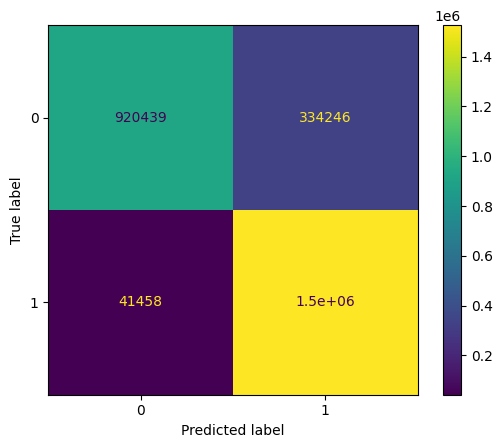

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

train_pred = xgb_model.predict(X_train_smote)

cm_train = confusion_matrix(y_train_smote, train_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_train,
    display_labels=[0,1]
)

disp.plot()
plt.show()

In [33]:
from sklearn.metrics import accuracy_score

train_pred = xgb_model.predict(X_train_smote)

train_accuracy = accuracy_score(y_train_smote, train_pred)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.8669151929018414


In [36]:
from sklearn.metrics import accuracy_score

test_pred = xgb_model.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, test_pred)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8568067837459462


In [35]:
import pickle

with open("loan_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

print("Model saved successfully!")

Model saved successfully!
